# Exploratory Data Analysis

#### Melakukan exploratory data analysis (EDA) untuk mendapatkan insight dari data 

##### Kategori: Menemukan Pola (Finding Patterns)
###### Tujuannya adalah memahami tren target jenjang pendidikan dan tipe event (Online/Offline) yang mendominasi pasar.
###### Pertanyaan Bisnis: "Target jenjang pendidikan dan tipe pelaksanaan event apa yang paling banyak tersedia di pasar untuk menentukan prioritas segmentasi di halaman utama portal Teemo?"
###### Analisis: Membantu tim menentukan segmentasi user utama sehingga visualisasi filter pencarian Teemo bisa lebih relevan sejak awal digunakan.

##### Kategori: Menemukan Hubungan (Finding Connections)
###### Tujuannya adalah menganalisis apakah jenis atau tema lomba tertentu memiliki korelasi langsung dengan tingkat biaya pendaftaran.
###### Pertanyaan Bisnis: "Bagaimana hubungan antara kategori utama lomba dengan besaran rata-rata biaya pendaftaran (Biaya_Rata_Rata) yang dipatok oleh penyelenggara?"
###### Analisis: Membantu tim marketing Teemo memetakan daya beli pengguna serta membantu penyelenggara menentukan harga pasar (market pricing) yang ideal.

##### Kategori: Mengategorikan Berbagai Hal (Categorizing Things)
###### Tujuannya adalah mengoptimalkan sistem rekomendasi collaborative filtering yang sedang dibangun oleh tim AI Engineer.
###### Pertanyaan Bisnis: "Berdasarkan frekuensi tertinggi, kategori apa saja yang menguasai ekosistem suplai kompetisi untuk menjadi dasar rekomendasi personal bagi pengguna?"
###### Analisis: Data hasil pengelompokan ini akan menjadi dasar bagi AI Engineer dalam merancang model rekomendasi Teemo yang lebih cerdas dan lintas disiplin.

##### Kategori: Menemukan Sesuatu yang Tidak Biasa (Finding Unusual Things)
###### Tujuannya adalah mengidentifikasi peluang tersembunyi (anomali pasar) sebagai magnet akuisisi pengguna baru secara organik.
###### Pertanyaan Bisnis: "Apakah terdapat event yang dilaksanakan secara luring/gabungan (Offline/Hybrid) namun pendaftarannya sepenuhnya gratis (Rp0) untuk dijadikan hero content?"
###### Analisis: Mengidentifikasi event bernilai tinggi tanpa hambatan finansial yang bisa dijadikan bahan promosi atau push notification eksklusif bagi user Teemo.

##### Kategori: Membuat Prediksi (Making Predictions)
###### Tujuannya adalah perencanaan lini masa (timeline) kampanye pemasaran fitur utama yaitu pembentukan tim ("Rooms").
###### Pertanyaan Bisnis: "Berdasarkan tren historis bulan mulainya kompetisi (Tanggal_Mulai), kapan periode puncak (peak season) event terjadi dalam setahun?"
###### Analisis: Memastikan tim pemasaran Teemo mengeksekusi promosi fitur kolaborasi secara agresif tepat 1 hingga 1,5 bulan sebelum puncak acara.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load dataset baru
df = pd.read_csv('data_clean.csv')

# Konversi kolom tanggal menjadi format datetime
df['Tanggal_Mulai'] = pd.to_datetime(df['Tanggal_Mulai'])
df['Tanggal_Selesai'] = pd.to_datetime(df['Tanggal_Selesai'])

# Ekstrak Kategori Utama (mengambil tag pertama jika terdapat beberapa kategori)
df['Kategori_Utama'] = df['Tema/Kategori'].apply(lambda x: str(x).split(',')[0].strip())

print("Informasi Dataset Baru:")
df.info()

Informasi Dataset Baru:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Judul                  1492 non-null   object        
 1   Jenjang                1492 non-null   object        
 2   Tipe (Online/Offline)  1492 non-null   object        
 3   Penyelenggara          1492 non-null   object        
 4   Tema/Kategori          1492 non-null   object        
 5   Link Poster            1492 non-null   object        
 6   Biaya_Rata_Rata        1492 non-null   int64         
 7   Tanggal_Mulai          1492 non-null   datetime64[ns]
 8   Tanggal_Selesai        1492 non-null   datetime64[ns]
 9   Kategori_Utama         1492 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(7)
memory usage: 116.7+ KB


# LANGKAH

### A. Eksplorasi Bidang Utama (Menemukan Pola)
#### Kami menganalisis distribusi penyelenggaraan event dan format pelaksanaannya untuk menentukan prioritas segmentasi di portal Teemo.

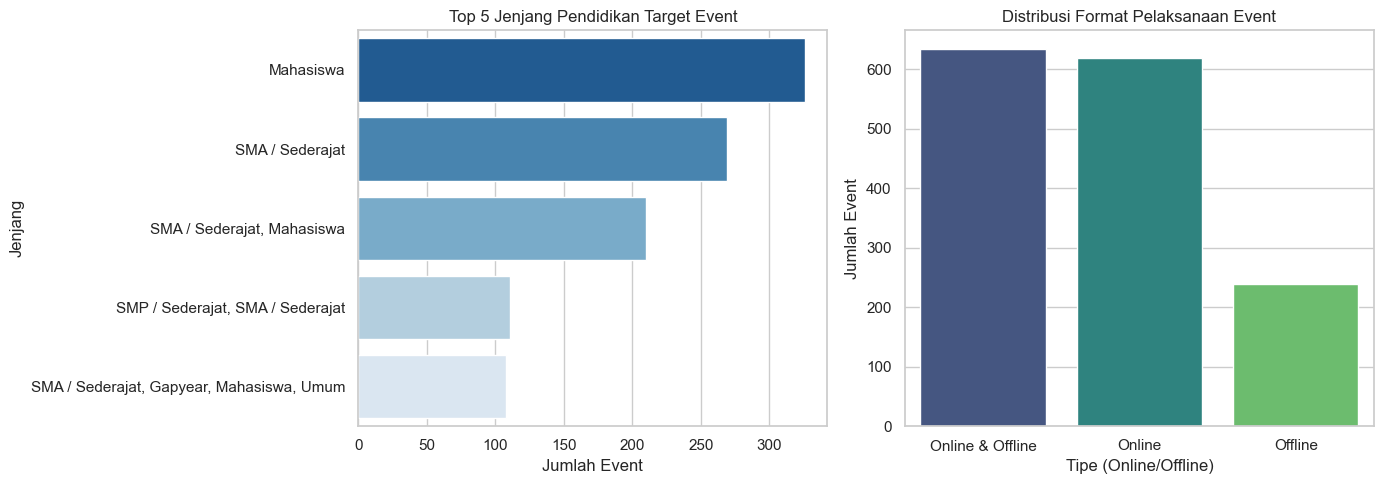

In [3]:
# Set tema visualisasi
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribusi Target Jenjang Pendidikan (Top 5)
jenjang_counts = df['Jenjang'].value_counts().head(5)
sns.barplot(ax=axes[0], x=jenjang_counts.values, y=jenjang_counts.index, palette='Blues_r')
axes[0].set_title('Top 5 Jenjang Pendidikan Target Event')
axes[0].set_xlabel('Jumlah Event')

# 2. Distribusi Tipe Event
tipe_counts = df['Tipe (Online/Offline)'].value_counts()
sns.barplot(ax=axes[1], x=tipe_counts.index, y=tipe_counts.values, palette='viridis')
axes[1].set_title('Distribusi Format Pelaksanaan Event')
axes[1].set_ylabel('Jumlah Event')

plt.tight_layout()
plt.show()

### insight:
1. Dominasi Target Pasar: Penyelenggaraan event sangat berpusat pada kelompok Mahasiswa (326 event) dan SMA / Sederajat (269 event). Kelompok usia produktif dan akademis ini menjadi pilar utama pergerakan trafik di Indonesia.
2. Pergeseran Format Digital: Format pelaksanaan didominasi oleh Online & Offline (Hybrid) (634 event) dan murni Online (619 event). Event yang sepenuhnya Offline hanya berada di angka 239 event. Penyelenggara cenderung memilih jalan tengah (hybrid) untuk menekan budget operasional sekaligus memperluas jangkauan pendaftar secara nasional.
3. Aksi Strategis untuk Teemo: Proses onboarding pengguna di Teemo harus langsung mengarahkan preferensi pencarian ke tingkat Mahasiswa/SMA dan mengutamakan opsi event berbasis daring/hybrid agar user langsung mendapatkan opsi yang relevan dengan tren pasar saat ini.

Selanjutnya kami menganalisis hubungan antara jenis kategori lomba dengan biaya pendaftarannya. Di sini, kita akan memetakan rumpun kategori mana saja yang mematok tarif premium agar portal Teemo dapat memberikan transparansi finansial serta rekomendasi persiapan yang tepat bagi pengguna.

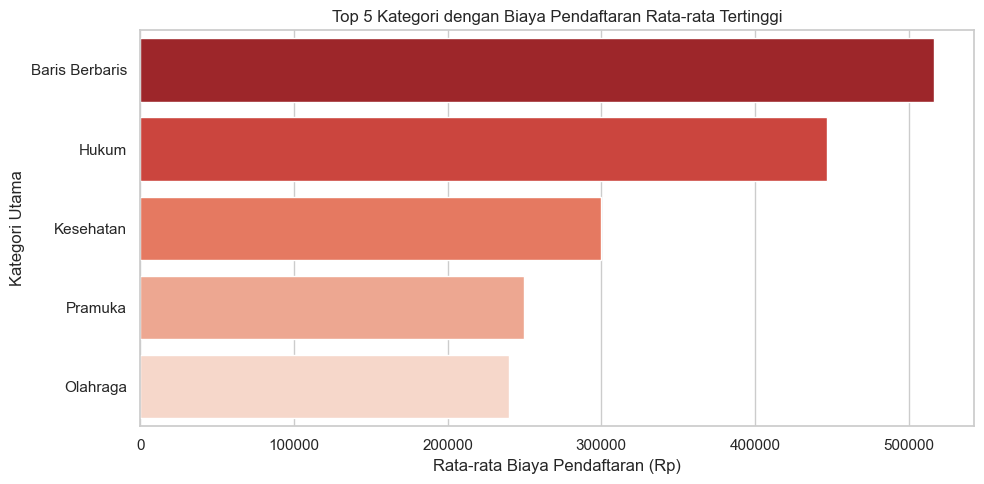

In [4]:
# Mengelompokkan biaya pendaftaran rata-rata berdasarkan kategori utama
biaya_by_kategori = df.groupby('Kategori_Utama')['Biaya_Rata_Rata'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x=biaya_by_kategori.values, y=biaya_by_kategori.index, palette='Reds_r')
plt.title('Top 5 Kategori dengan Biaya Pendaftaran Rata-rata Tertinggi')
plt.xlabel('Rata-rata Biaya Pendaftaran (Rp)')
plt.ylabel('Kategori Utama')

plt.tight_layout()
plt.show()

#### insight: 
1. Lomba Berbiaya Premium: Kategori lomba yang membutuhkan instrumen fisik, lokasi khusus, atau penilai tersertifikasi di lapangan seperti Baris Berbaris (rata-rata ~Rp516.000) dan Hukum (~Rp447.000) mematok tarif tertinggi di pasar.
2. Aksi Strategis untuk Teemo: Teemo dapat memperkenalkan label khusus seperti "Premium Event" untuk lomba berbiaya tinggi. Di dalam halaman detail tersebut, sistem harus memberikan pengingat atau fasilitas pematangan tim yang lebih ketat, karena pengguna yang berinvestasi besar tentu menuntut persiapan kelompok yang jauh lebih matang demi menghindari kerugian finansial.

Selanjutnya kami akan memetakan kategori event yang paling populer di pasar. Di sini, kita akan melihat suplai ekosistem utama yang nantinya akan menjadi fondasi bagi tim AI Engineer dalam merancang sistem rekomendasi (Collaborative Filtering) secara cerdas.

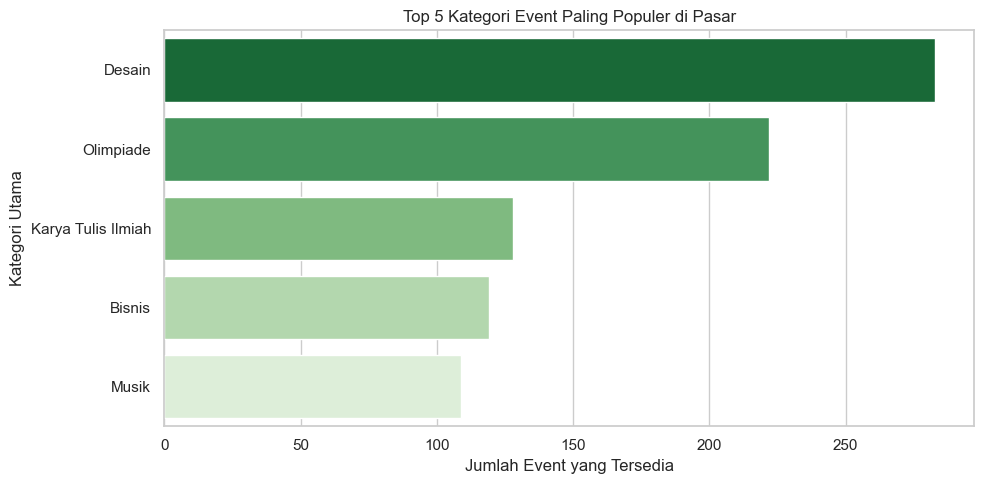

In [5]:
# Menghitung frekuensi event per kategori utama
kategori_counts = df['Kategori_Utama'].value_counts().head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x=kategori_counts.values, y=kategori_counts.index, palette='Greens_r')
plt.title('Top 5 Kategori Event Paling Populer di Pasar')
plt.xlabel('Jumlah Event yang Tersedia')
plt.ylabel('Kategori Utama')

plt.tight_layout()
plt.show()

#### Insight:
1. Raja Pasar Kompetisi: Bidang kreatif dan akademis murni menguasai suplai acara. Desain menempati posisi teratas dengan 283 event, disusul oleh Olimpiade (222 event) dan Karya Tulis Ilmiah (KTI) (128 event).
2. Aksi untuk AI Engineer (Collaborative Filtering): Sistem rekomendasi Teemo tidak boleh mengotakkan user secara kaku. Karena Desain, Olimpiade, dan KTI adalah pilar terbesar, model AI harus memanfaatkan anchor points lintas disiplin. Pengguna yang sering melihat lomba KTI (Karya Tulis Ilmiah) sebaiknya secara cerdas direkomendasikan ke lomba kategori Bisnis, karena luaran KTI sering kali memerlukan validasi model bisnis (pitch deck).

Selanjutnya kami mencari anomali pasar. Di sini, kita akan memfilter data khusus untuk menemukan event-event bernilai tinggi yang bisa dijadikan magnet akuisisi organik.

In [6]:
# Mencari event yang memiliki unsur offline tetapi biayanya Rp0
unusual_events = df[(df['Tipe (Online/Offline)'].str.contains('Offline', case=False, na=False)) & 
                    (df['Biaya_Rata_Rata'] == 0)]

print(f"Total event anomali (Offline/Hybrid & Gratis): {len(unusual_events)} event")
# Menampilkan sampel 5 teratas
display(unusual_events[['Judul', 'Penyelenggara', 'Tema/Kategori']].head())

Total event anomali (Offline/Hybrid & Gratis): 174 event


,Judul,Penyelenggara,Tema/Kategori
32,Video Creative Competition,Jakarta Garden City,"Videografi/Film, Challenge"
37,Jagoan Hosting Infra Competitions,Jagoan Hosting,IT
40,MBION Champion Quest 2025,HMDM UISI,Bisnis
43,LANGUAGE COMPETITION JUNIOR 2026,SMP ISTIQOMAH SAMBAS PURBALINGGA BOARDING SCHOOL,"Sastra, Agama, Pidato"
50,GEN EXPO 2025,GenBI UNSIKA,"Desain, Bisnis"


#### Insight:
1. Temuan Anomali Positif: Ditemukan sebanyak 174 event berbasis luring/hybrid yang sepenuhnya gratis (Rp0). Contoh acaranya meliputi Video Creative Competition oleh Jakarta Garden City dan GEN EXPO 2025 oleh GenBI Unsika. Event seperti ini biasanya disokong penuh oleh korporasi besar atau kampus terkemuka.
2. Aksi Strategis untuk Teemo: Event bernilai tinggi tanpa modal ini adalah umpan terbaik (hero content) untuk mendatangkan user baru. Tim Growth Teemo dapat membuat filter eksklusif atau notifikasi push khusus dengan tajuk "Event Luring Populer - Gratis 100%". Hal ini akan memicu konversi pendaftaran user secara masif.

Selanjutnya yaitu mengenai prediksi Peak Season

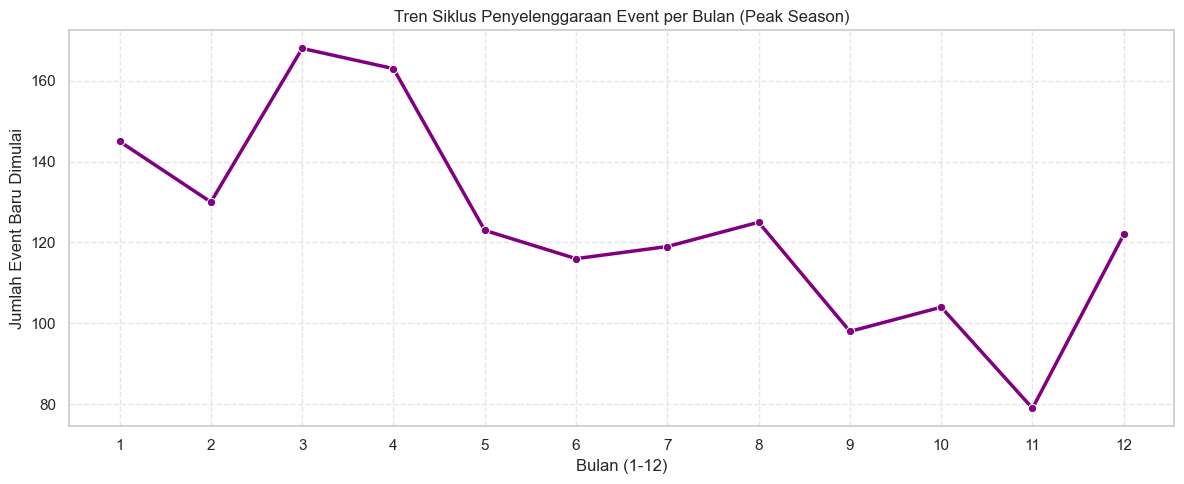

In [7]:
# Ekstrak bulan dari Tanggal Mulai
df['Bulan_Mulai'] = df['Tanggal_Mulai'].dt.month
peak_months = df['Bulan_Mulai'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=peak_months.index, y=peak_months.values, marker='o', color='purple', linewidth=2.5)
plt.title('Tren Siklus Penyelenggaraan Event per Bulan (Peak Season)')
plt.xlabel('Bulan (1-12)')
plt.ylabel('Jumlah Event Baru Dimulai')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Insight:
1. Siklus Peak Season: Lonjakan tajam dimulainya event terjadi pada rentang awal hingga pertengahan tahun, memuncak di bulan Maret (168 event) dan April (163 event).
2. Aksi Strategis untuk Fitur "Rooms" Teemo: Fitur pencarian rekan tim (Rooms) di Teemo bekerja sebagai wadah pra-pendaftaran. Mengingat pengguna membutuhkan waktu beberapa minggu untuk berdiskusi dan menyamakan jadwal, kampanye pemasaran fitur "Rooms" harus diledakkan 1 hingga 1,5 bulan sebelum puncak acara, yaitu pada bulan Januari dan Februari. Di bulan tersebut, urgensi peserta untuk mengamankan partner lomba berada di titik tertinggi.